In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

In [2]:
fake = pd.read_csv("fake.csv")
true = pd.read_csv("true.csv")

print(fake.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [3]:
fake["label"] = 1   # fake news
true["label"] = 0   # real news

In [4]:
fake = fake[["text","label"]]
true = true[["text","label"]]

In [5]:
df = pd.concat([fake,true])

df = df.sample(frac=1)   # shuffle dataset

df.reset_index(drop=True, inplace=True)

print(df.head())

                                                text  label
0  WASHINGTON (Reuters) - U.S. President-elect Do...      0
1  WASHINGTON (Reuters) - Twelve U.S. senators ur...      0
2  WASHINGTON (Reuters) - U.S. Vice President Joe...      0
3        https://www.youtube.com/watch?v=rUr8pYr5AXs      1
4  ANKARA/ISTANBUL (Reuters) - Turkey criticized ...      0


In [6]:
texts = df["text"]
labels = df["label"]

In [7]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

In [8]:
x = pad_sequences(sequences, maxlen=200)

y = np.array(labels)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [10]:
model = Sequential()

model.add(Embedding(5000,64,input_length=200))
model.add(LSTM(64))
model.add(Dense(1,activation="sigmoid"))

C:\Users\sindh\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 67s 57ms/step - accuracy: 0.9713 - loss: 0.0876 - val_accuracy: 0.9820 - val_loss: 0.0559
Epoch 2/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 69s 61ms/step - accuracy: 0.9828 - loss: 0.0536 - val_accuracy: 0.9702 - val_loss: 0.1083
Epoch 3/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 68s 61ms/step - accuracy: 0.9840 - loss: 0.0508 - val_accuracy: 0.9612 - val_loss: 0.1123
Epoch 4/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 69s 61ms/step - accuracy: 0.9896 - loss: 0.0322 - val_accuracy: 0.9910 - val_loss: 0.0302
Epoch 5/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 72s 64ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9939 - val_loss: 0.0221


In [13]:
loss, accuracy = model.evaluate(x_test,y_test)

print("Test Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9939 - loss: 0.0221
Test Accuracy: 0.99387526512146


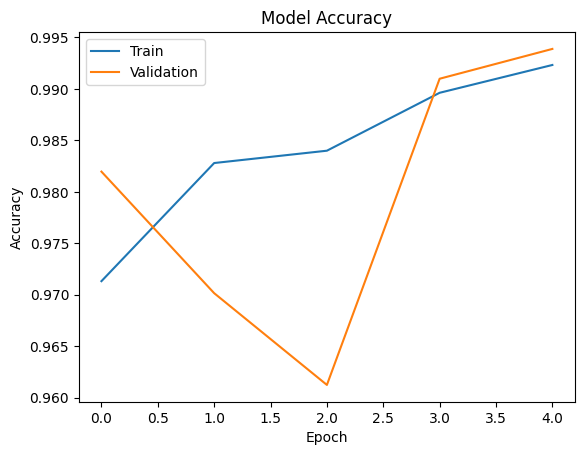

In [14]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [15]:
news = ["Aliens landed in New York City yesterday"]

seq = tokenizer.texts_to_sequences(news)
pad = pad_sequences(seq,maxlen=200)

prediction = model.predict(pad)

if prediction > 0.5:
    print("Fake News")
else:
    print("Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Fake News
